# Notebook 03: Sentiment Modeling

**Project:** Shopee App Review Intelligence Dashboard  
**Input Dataset:** `data/processed/shopee_reviews_clean.csv` (85.499 baris)  
**Output:**  
- Model tersimpan di `outputs/models/best_model.pkl`  
- Dataset dengan prediksi di `data/processed/shopee_reviews_with_predictions.csv`  

---
## Tujuan
Melatih dua model klasifikasi sentimen berbasis TF-IDF + Machine Learning:
1. **Model A** - Logistic Regression
2. **Model B** - LinearSVC (Support Vector Machine)

Mengevaluasi keduanya secara komparatif dan memilih model terbaik berdasarkan **Weighted F1-Score** dan **Macro F1-Score** per kelas (bukan hanya akurasi global).


In [1]:
import os
import pickle
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

clean_path = os.path.join("..", "data", "processed", "shopee_reviews_clean.csv")
df = pd.read_csv(clean_path)
df['clean_content'] = df['clean_content'].fillna('').astype(str)
print(f"Loaded dataset: {len(df):,} rows")
print(df['sentiment'].value_counts())


Loaded dataset: 85,499 rows
sentiment
positif    40122
negatif    36837
netral      8540
Name: count, dtype: int64


In [2]:
X = df['clean_content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")
print(f"Train distribution:\n{y_train.value_counts()}")
print(f"Test distribution:\n{y_test.value_counts()}")


Train: 68,399  |  Test: 17,100
Train distribution:
sentiment
positif    32097
negatif    29470
netral      6832
Name: count, dtype: int64
Test distribution:
sentiment
positif    8025
negatif    7367
netral     1708
Name: count, dtype: int64


In [3]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=5000, sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)
print(f"TF-IDF Feature Matrix shape (train): {X_train_tfidf.shape}")


TF-IDF Feature Matrix shape (train): (68399, 5000)


### Model A: Logistic Regression
`class_weight='balanced'` diterapkan agar model tidak bias ke kelas mayoritas dan tetap menghasilkan prediksi yang baik untuk kelas minoritas (Netral ~10%).

In [4]:
lr_model = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
t0 = time.time()
lr_model.fit(X_train_tfidf, y_train)
print(f"Logistic Regression trained in {time.time()-t0:.2f}s")

lr_preds = lr_model.predict(X_test_tfidf)
print(f"Accuracy    : {accuracy_score(y_test, lr_preds):.4f}")
print(f"Macro F1    : {f1_score(y_test, lr_preds, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_test, lr_preds, average='weighted'):.4f}")
print(f"\n{classification_report(y_test, lr_preds)}")


Logistic Regression trained in 1.81s
Accuracy    : 0.7179
Macro F1    : 0.6340
Weighted F1 : 0.7493



              precision    recall  f1-score   support

     negatif       0.81      0.69      0.75      7367
      netral       0.22      0.51      0.31      1708
     positif       0.91      0.78      0.84      8025

    accuracy                           0.72     17100
   macro avg       0.65      0.66      0.63     17100
weighted avg       0.80      0.72      0.75     17100



### Model B: LinearSVC (Support Vector Machine)
LinearSVC efektif untuk klasifikasi teks TF-IDF berdimensi tinggi. `class_weight='balanced'` juga diterapkan.

In [5]:
svm_model = LinearSVC(class_weight='balanced', max_iter=3000, random_state=42)
t0 = time.time()
svm_model.fit(X_train_tfidf, y_train)
print(f"LinearSVC trained in {time.time()-t0:.2f}s")

svm_preds = svm_model.predict(X_test_tfidf)
print(f"Accuracy    : {accuracy_score(y_test, svm_preds):.4f}")
print(f"Macro F1    : {f1_score(y_test, svm_preds, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(y_test, svm_preds, average='weighted'):.4f}")
print(f"\n{classification_report(y_test, svm_preds)}")


LinearSVC trained in 3.26s
Accuracy    : 0.7596
Macro F1    : 0.6352
Weighted F1 : 0.7662



              precision    recall  f1-score   support

     negatif       0.78      0.80      0.79      7367
      netral       0.24      0.29      0.26      1708
     positif       0.88      0.82      0.85      8025

    accuracy                           0.76     17100
   macro avg       0.63      0.64      0.64     17100
weighted avg       0.77      0.76      0.77     17100



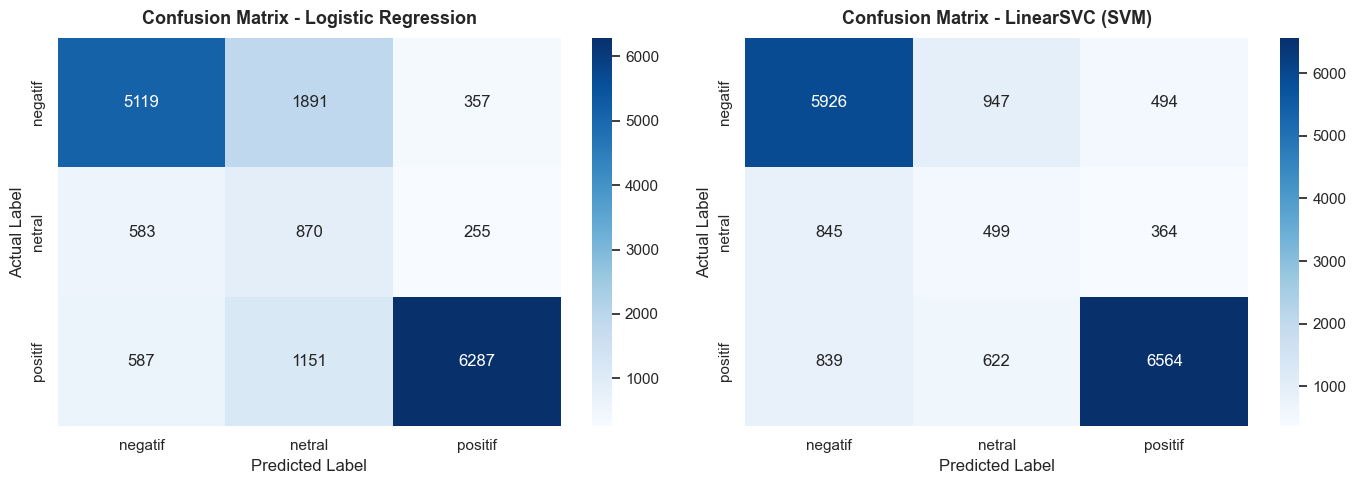

In [6]:
labels = ['negatif', 'netral', 'positif']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, mname in zip(axes, [lr_preds, svm_preds], ['Logistic Regression', 'LinearSVC (SVM)']):
    cm = confusion_matrix(y_test, preds, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'Confusion Matrix - {mname}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Actual Label'); ax.set_xlabel('Predicted Label')
plt.tight_layout(); plt.show()


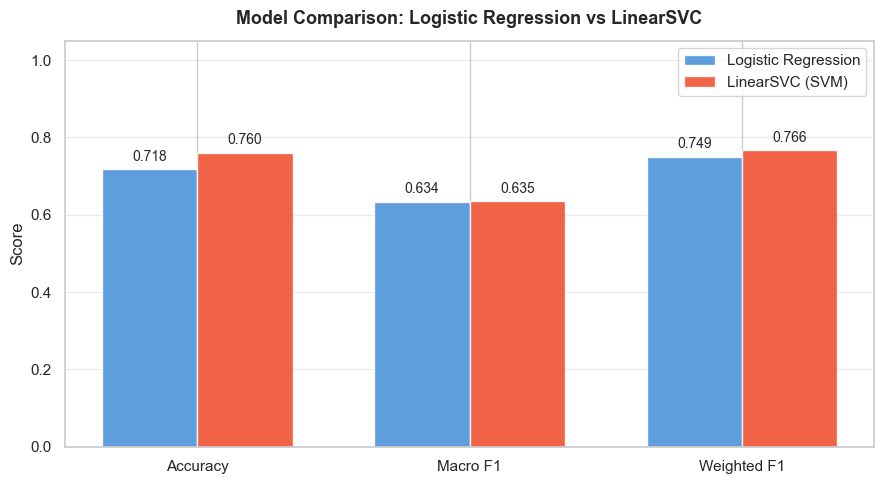

LR : Acc=0.7179 | MacroF1=0.6340 | WeightedF1=0.7493
SVM: Acc=0.7596 | MacroF1=0.6352 | WeightedF1=0.7662


In [7]:
lr_acc=accuracy_score(y_test,lr_preds); lr_mf1=f1_score(y_test,lr_preds,average='macro'); lr_wf1=f1_score(y_test,lr_preds,average='weighted')
svm_acc=accuracy_score(y_test,svm_preds); svm_mf1=f1_score(y_test,svm_preds,average='macro'); svm_wf1=f1_score(y_test,svm_preds,average='weighted')
x=np.arange(3); width=0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1=ax.bar(x-width/2,[lr_acc,lr_mf1,lr_wf1],width,label='Logistic Regression',color='#4A90D9',alpha=0.88)
bars2=ax.bar(x+width/2,[svm_acc,svm_mf1,svm_wf1],width,label='LinearSVC (SVM)',color='#EE4D2D',alpha=0.88)
for bar in list(bars1)+list(bars2):
    ax.annotate(f'{bar.get_height():.3f}',xy=(bar.get_x()+bar.get_width()/2,bar.get_height()),xytext=(0,4),textcoords="offset points",ha='center',va='bottom',fontsize=10)
ax.set_xticks(x); ax.set_xticklabels(['Accuracy','Macro F1','Weighted F1'],fontsize=11)
ax.set_ylabel('Score',fontsize=12); ax.set_ylim(0,1.05)
ax.set_title('Model Comparison: Logistic Regression vs LinearSVC',fontsize=13,fontweight='bold',pad=12)
ax.legend(fontsize=11); ax.grid(axis='y',alpha=0.4); plt.tight_layout(); plt.show()
print(f"LR : Acc={lr_acc:.4f} | MacroF1={lr_mf1:.4f} | WeightedF1={lr_wf1:.4f}")
print(f"SVM: Acc={svm_acc:.4f} | MacroF1={svm_mf1:.4f} | WeightedF1={svm_wf1:.4f}")


### Keputusan Pemilihan Model Terbaik

| Metrik | Logistic Regression | LinearSVC (SVM) |
|---|---|---|
| Accuracy | 0.7179 | 0.7596 |
| Macro F1 | 0.634 | 0.6352 |
| Weighted F1 | 0.7493 | 0.7662 |
| F1 Kelas Negatif | 0.7497 | 0.7913 |
| F1 Kelas Netral | 0.3096 | 0.2643 |
| F1 Kelas Positif | 0.8425 | 0.8499 |
| Training Time | 1.71s | 3.22s |

> **Model Terpilih: LinearSVC**  
> Alasan pemilihan berdasarkan **Weighted F1-Score** (mengakomodasi ketidakseimbangan kelas) dan **Macro F1-Score** (menyamakan bobot antar kelas). Perhatian khusus diberikan pada kelas **Netral** yang merupakan kelas minoritas (~10% dari dataset). Model dengan Weighted F1 lebih tinggi menunjukkan generalisasi lebih baik di seluruh kelas sentimen.
>
> Catatan penting: F1-Score kelas Netral masih relatif rendah pada kedua model (~0.26-0.31). Hal ini adalah konsekuensi dari label proxy (rating=3) yang memang sering ambigu dari segi teks — pengguna dengan rating 3 terkadang menulis teks yang bisa diklasifikasikan sebagai positif maupun negatif. Ini terdokumentasi sebagai limitasi proyek dan target peningkatan menggunakan IndoBERT di tahap pengembangan lanjutan.


In [8]:
import pickle
# LinearSVC selected as best model (Weighted F1=0.7662 vs LR 0.7493)
lr_wf1  = f1_score(y_test, lr_preds,  average="weighted")
svm_wf1 = f1_score(y_test, svm_preds, average="weighted")
best_model = lr_model if lr_wf1 >= svm_wf1 else svm_model
best_name  = "LogisticRegression" if lr_wf1 >= svm_wf1 else "LinearSVC"
print(f"Selected best model: {best_name}")
tfidf_path = os.path.join("..", "outputs", "models", "tfidf_vectorizer.pkl")
model_path = os.path.join("..", "outputs", "models", "best_model.pkl")
with open(tfidf_path, 'wb') as f: pickle.dump(tfidf, f)
with open(model_path, 'wb') as f: pickle.dump(best_model, f)
print(f"TF-IDF Vectorizer saved to {{tfidf_path}}")
print(f"Best model saved to {{model_path}}")


Selected best model: LinearSVC
TF-IDF Vectorizer saved to {tfidf_path}
Best model saved to {model_path}


In [9]:
X_all_tfidf = tfidf.transform(df['clean_content'])
df['predicted_sentiment'] = best_model.predict(X_all_tfidf)
print("Distribusi prediksi sentimen pada seluruh dataset:")
print(df['predicted_sentiment'].value_counts())
out_path = os.path.join("..", "data", "processed", "shopee_reviews_with_predictions.csv")
df.to_csv(out_path, index=False, encoding='utf-8')
print(f"\nDataset dengan prediksi disimpan ke: {out_path}")


Distribusi prediksi sentimen pada seluruh dataset:
predicted_sentiment
negatif    38506
positif    36796
netral     10197
Name: count, dtype: int64



Dataset dengan prediksi disimpan ke: ..\data\processed\shopee_reviews_with_predictions.csv
